# LIBRAIRIES

In [20]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from nucleo.io.reading import checking_parameters
from nucleo.io.reading import reading_one_parquet
from nucleo.io.reading import finding_one_parquet
from nucleo.io.reading import reading_all_parquet

# I.1 : DATA - READING

In [3]:
root_i = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-05-01/nucleo__lshigh__17/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=100__bpmin=0__mu=130__theta=63__rcapt=1.7e-01__rrest=1.7e-01__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__"
df_i = reading_one_parquet(root_i)
print(df_i.columns)


root_j = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-30/nucleo__actifull__17/algo=2S__fact=True__mode=actifull__dstr=False__land=periodic__s=35__l=10__bpmin=0__mu=150__theta=50__rcapt=1.7e-01__rrest=1.7e-01__alphac=6.0e-01__alphad=0.0e+00__alphar=4.0e-01__krel=1.0e+00__Kp=4.0e-01__Kz=3.0e-01__nt=1.0e+04__"
df_j = reading_one_parquet(root_j)
print(df_j.columns)

['algo', 'fact', 'mode', 'dstr', 'land', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'krel', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'times', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_a', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 't_matrix', 'x_matrix', 'results', 'obstacles', 's_points', 's_distrib', 'l_points', 'l_distrib', 'l_view', 'p', 'results_mean', 'results_med', 'results_std', 'pos_hist', 'xbj_points', 'xbj_distrib', 'tbj_points', 'tbj_distrib', 'fpt_distrib', 'fpt_number', 'dx_points', 'dx_distrib', 'dx_mean', 'dx_med', 'dx_mp', 'dt_points', 'dt_distrib', 'dt_mean', 'dt_med', 'dt_mp', 'vi_points', 'vi_distrib', 'alpha0', 'xt_over_t', 'G', 'bound_low', 'bound_high', 'lb']
['algo', 'fact', 'mode', 'dstr', 'land', 's', 'l', 

In [4]:
# ── NUCLEO ──────────────────────────────────────────────────────────────────────

# Reading NUCLEO
root_nucleo = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-05-01"
df_all_nucleo = reading_all_parquet(root_nucleo)
print(df_all_nucleo.shape)
print(df_all_nucleo.columns)

# Params NUCLEO
params_all_nucleo = checking_parameters(df_all_nucleo)
print(params_all_nucleo)


# ── FACT ──────────────────────────────────────────────────────────────────────

# Reading FACT
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-30"
df_all_fact = reading_all_parquet(root_fact)
print(df_all_fact.shape)
print(df_all_fact.columns)

# Params FACT
params_all_fact = checking_parameters(df_all_fact)
print(params_all_fact)


# ── CHECK ──────────────────────────────────────────────────────────────────────

if df_all_nucleo.columns == df_all_fact.columns:
    print("\n# ──  Ready for study ── #")

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:141: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


(131300, 61)
['algo', 'fact', 'mode', 'dstr', 'land', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'krel', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 'dx_mean', 'dx_med', 'dx_mp', 'dt_mean', 'dt_med', 'dt_mp', 'alpha0', 'bound_low', 'bound_high', 'lb']
{'algo': ['1S'], 'fact': [False], 'mode': ['none'], 'dstr': [False], 'land': ['homogen', 'periodic', 'random'], 's': [150], 'l': [5, 10, 15, 20, 25, 50, 100, 150], 'bpmin': [0, 5, 10, 15], 'mu': [100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320,

# I.2 : DATA - CHECKING

In [5]:
# ── NUCLEO ──────────────────────────────────────────────────────────────────────

# Params
params_single_nucleo = {
    "algo"      : "1S",
    "fact"      : False,
    "mode"      : "none",
    "dstr"      : False, 
    "land"      : "periodic",
    "s"         : 150,
    "l"         : 10,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 100,
    "alphar"    : 0.00,
    "Kp"        : 0.00,
    "Kz"        : 0.00
}

# Reading
df_single_nucleo = finding_one_parquet(root=root_nucleo, params=params_single_nucleo)
print(df_single_nucleo)


# ── FACT ──────────────────────────────────────────────────────────────────────

# Params
params_fact = {
    **params_single_nucleo,
    "algo"      : "2S",
    "fact"      : True,
    "mode"      : "passfull",
    "s"         : 35,
    "l"         : 10,
}

# Reading
df_single_fact = finding_one_parquet(root=root_fact, params=params_fact)
print(df_single_fact)

# ── CHECK ──────────────────────────────────────────────────────────────────────

if df_single_nucleo.columns == df_single_fact.columns:
    print("\n# ──  Ready for study ── #")

['algo', 'fact', 'mode', 'dstr', 'land', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'krel', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'times', 'binx', 'bint', 'nt', 's_mean', 'l_mean', 'alpha_mean_a', 'alpha_mean_v', 'alpha_mean_c', 'v_mean', 'v_med', 'v_mean_th', 'v_mean_th_eff', 'vf', 'Cf', 'wf', 'vf_std', 'Cf_std', 'wf_std', 'vi_mean', 'vi_med', 'vi_mp', 'vc_mean', 'vc_med', 't_matrix', 'x_matrix', 'results', 'obstacles', 's_points', 's_distrib', 'l_points', 'l_distrib', 'l_view', 'p', 'results_mean', 'results_med', 'results_std', 'pos_hist', 'xbj_points', 'xbj_distrib', 'tbj_points', 'tbj_distrib', 'fpt_distrib', 'fpt_number', 'dx_points', 'dx_distrib', 'dx_mean', 'dx_med', 'dx_mp', 'dt_points', 'dt_distrib', 'dt_mean', 'dt_med', 'dt_mp', 'vi_points', 'vi_distrib', 'alpha0', 'xt_over_t', 'G', 'bound_low', 'bound_high', 'lb']
Scanning 131300 parquet files...
Found in : ['/home

# I.3 : DATA - VERIFICATION

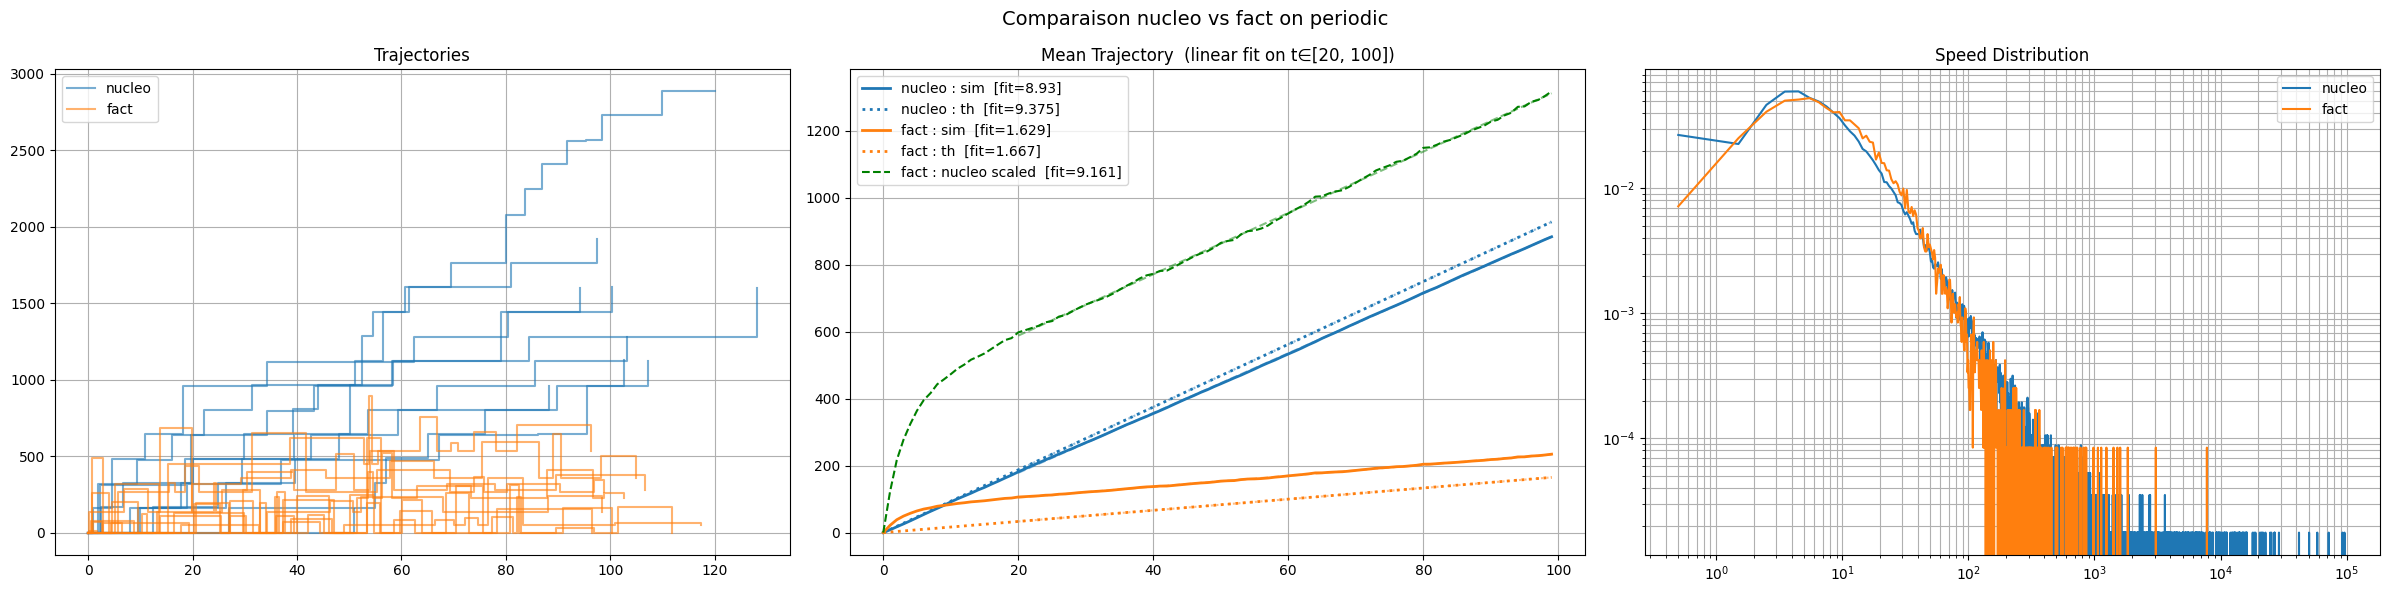

In [6]:
def plot_df_main_info(dfs: list[tuple[pl.DataFrame, pl.DataFrame, str]], title: str = "") -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(24, 6))
    if title:
        fig.suptitle(title, fontsize=14)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    FIT_T_MIN, FIT_T_MAX = 20, 100

    def linear_fit_and_plot(ax, t, y, color, ls):
        mask = (t >= FIT_T_MIN) & (t <= FIT_T_MAX)
        if mask.sum() < 2:
            return
        slope, intercept = np.polyfit(t[mask], y[mask], 1)
        ax.plot(t[mask], slope * t[mask] + intercept,
                color=color, ls=ls, lw=1.5, alpha=0.5)
        return slope

    for idx, (df, df_other, label) in enumerate(dfs):
        color = colors[idx % len(colors)]

        # --- Trajectories ---
        x1 = df["t_matrix"][0].to_numpy()
        y1 = df["x_matrix"][0].to_numpy()
        for i in range(10):
            ax1.plot(x1[i], y1[i], drawstyle="steps-mid", color=color,
                     alpha=0.6, label=label if i == 0 else None)

        # --- Mean Trajectory : Data ---
        times        = df["times"][0].to_numpy()
        results_mean = df["results_mean"][0].to_numpy()
        v_mean_th    = df["v_mean_th"][0]

        # --- Mean Trajectory : Simulation ---
        slope_sim = linear_fit_and_plot(ax2, times, results_mean, color, ls="--")
        ax2.plot(times, results_mean, color=color,
                 label=f"{label} : sim  [fit={slope_sim:.4g}]", ls="-", lw=2)

        # --- Mean Trajectory : Theory ---
        y_th = times * v_mean_th
        slope_th = linear_fit_and_plot(ax2, times, y_th, color, ls=":")
        ax2.plot(times, y_th, color=color,
                 label=f"{label} : th  [fit={slope_th:.4g}]", ls=":", lw=2)

        # --- Mean Trajectory : Scaling ---
        if "fact" in label:
            alphac = df["alphac"][0]
            rcapt  = df["rcapt"][0]
            rrest  = df["rrest"][0]
            lF     = df["l"][0]
            sF     = df["s"][0]
            lN     = df_other["l"][0]
            sN     = df_other["s"][0]
            factor = 1 / (1/rcapt + 1/rrest) * alphac * (lF / (lF + sF)) * ((sN + lN) / lN)
            y_scaled = results_mean / factor
            slope_sc = linear_fit_and_plot(ax2, times, y_scaled, "g", ls="--")
            ax2.plot(times, y_scaled, color="g",
                     label=f"{label} : nucleo scaled  [fit={slope_sc:.4g}]", ls="--")

        # --- Speed Distribution ---
        x3 = df["vi_points"][0].to_numpy()
        y3 = df["vi_distrib"][0].to_numpy()
        ax3.loglog(x3, y3, color=color, label=label)

    ax1.set_title("Trajectories")
    ax1.legend()
    ax1.grid(True, which="both")
    ax2.set_title(f"Mean Trajectory  (linear fit on t∈[{FIT_T_MIN}, {FIT_T_MAX}])")
    ax2.legend()
    ax2.grid(True, which="both")
    ax3.set_title("Speed Distribution")
    ax3.legend()
    ax3.grid(True, which="both")

    plt.tight_layout()
    plt.show()

plot_df_main_info(
    dfs=[
        (df_single_nucleo, df_single_fact, "nucleo"),
        (df_single_fact, df_single_nucleo, "fact"),
    ],
    title=f"Comparaison nucleo vs fact on {params_single_nucleo["land"]}"
)

# II.1 : STUDYING - DATA

In [7]:
# ── ADDING COLUMNS ──────────────────────────────────────────────────────────────────────

# Copying the file
df_all = df_all_fact.clone()
print(df_all)

# Reference Keys
group_keys = ["mu", "theta", "s", "l", "bpmin", "land"]

# Calculating R
df_all = df_all.with_columns(
    (pl.col("Kp") * pl.col("alphar")).alias("R")
)

# Références of R0 (Kp == 0) per group
df_ref = (
    df_all
    .filter(pl.col("R") == 0)
    .group_by(group_keys)
    .agg(
        pl.col("v_mean").mean().alias("v_mean_R0"),
        pl.col("wf").mean().alias("wf_R0"),
    )
)

# Adding Gv and Gw
df_all = (
    df_all
    .join(df_ref, on=group_keys, how="left")
    .with_columns(
        (pl.col("v_mean") / pl.col("v_mean_R0")).alias("Gv"),
        (pl.col("wf")     / pl.col("wf_R0"    )).alias("Gw"),
    )
    .drop(["v_mean_R0", "wf_R0"])
)
print(df_all)

shape: (52_272, 61)
┌──────┬──────┬──────────┬───────┬───┬────────┬───────────┬────────────┬─────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ alpha0 ┆ bound_low ┆ bound_high ┆ lb  │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ ---    ┆ ---       ┆ ---        ┆ --- │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ i64    ┆ i64       ┆ i64        ┆ i64 │
╞══════╪══════╪══════════╪═══════╪═══╪════════╪═══════════╪════════════╪═════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …      ┆ …         ┆ …          ┆ …   │
│ 2S   ┆ true ┆ passmemo ┆ false ┆ … ┆ 1      ┆ 5         ┆ 80         ┆ 20  │
│ 2S   ┆ true ┆ passmemo ┆ false

In [25]:
# ── SELECTING PARAMETERS ──────────────────────────────────────────────────────────────────────

# Values
s     = 35
l     = 10
bpmin = 0
mu    = 150
theta = 100
Kz    = 0.50

# Dict
params_fixed = {
    "fact"      : True,
    "algo"      : "2S",
    "s"         : s,
    "l"         : l,
    "bpmin"     : bpmin,
    "mu"        : mu,
    "theta"     : theta,
    "Kz"        : Kz     # Checking that is doesn't affect while null 
}

# Filter Function
def filter_df(df: pl.DataFrame, params: dict) -> pl.DataFrame:
    """Filtre df sur les clés/valeurs de params, en ignorant les valeurs None."""
    filters = [pl.col(k) == v for k, v in params.items() if v is not None]
    return df.filter(pl.all_horizontal(filters)) if filters else df

# DataFrame
df_work = filter_df(df_all, params_fixed)
print(df_work)

# Parameters Non Fixed
Kps     = np.unique(df_work["Kp"])
modes   = np.unique(df_work["mode"])
lands   = np.unique(df_work["land"])

# Prints
print(f"lands = {lands}")
print(f"modes = {modes}")
print(f"Kps   = {Kps}")

shape: (792, 64)
┌──────┬──────┬──────────┬───────┬───┬─────┬─────┬──────────┬──────────┐
│ algo ┆ fact ┆ mode     ┆ dstr  ┆ … ┆ lb  ┆ R   ┆ Gv       ┆ Gw       │
│ ---  ┆ ---  ┆ ---      ┆ ---   ┆   ┆ --- ┆ --- ┆ ---      ┆ ---      │
│ str  ┆ bool ┆ str      ┆ bool  ┆   ┆ i64 ┆ f64 ┆ f64      ┆ f64      │
╞══════╪══════╪══════════╪═══════╪═══╪═════╪═════╪══════════╪══════════╡
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 20  ┆ 0.0 ┆ 1.003721 ┆ 0.962843 │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 20  ┆ 0.0 ┆ 1.003595 ┆ 0.983235 │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 20  ┆ 0.0 ┆ 0.97614  ┆ 1.017054 │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 20  ┆ 0.0 ┆ 0.9988   ┆ 1.040792 │
│ 2S   ┆ true ┆ actifull ┆ false ┆ … ┆ 20  ┆ 0.0 ┆ 0.976379 ┆ 0.928059 │
│ …    ┆ …    ┆ …        ┆ …     ┆ … ┆ …   ┆ …   ┆ …        ┆ …        │
│ 2S   ┆ true ┆ passmemo ┆ false ┆ … ┆ 20  ┆ 0.6 ┆ 2.846861 ┆ 1.300442 │
│ 2S   ┆ true ┆ passmemo ┆ false ┆ … ┆ 20  ┆ 0.7 ┆ 3.183907 ┆ 1.34889  │
│ 2S   ┆ true ┆ passmemo ┆ false ┆

# II.2 : STUDYING - 

In [ ]:
# ── Scenarios in function of K and modes ──────────────────────────────────────────────────────────────────────





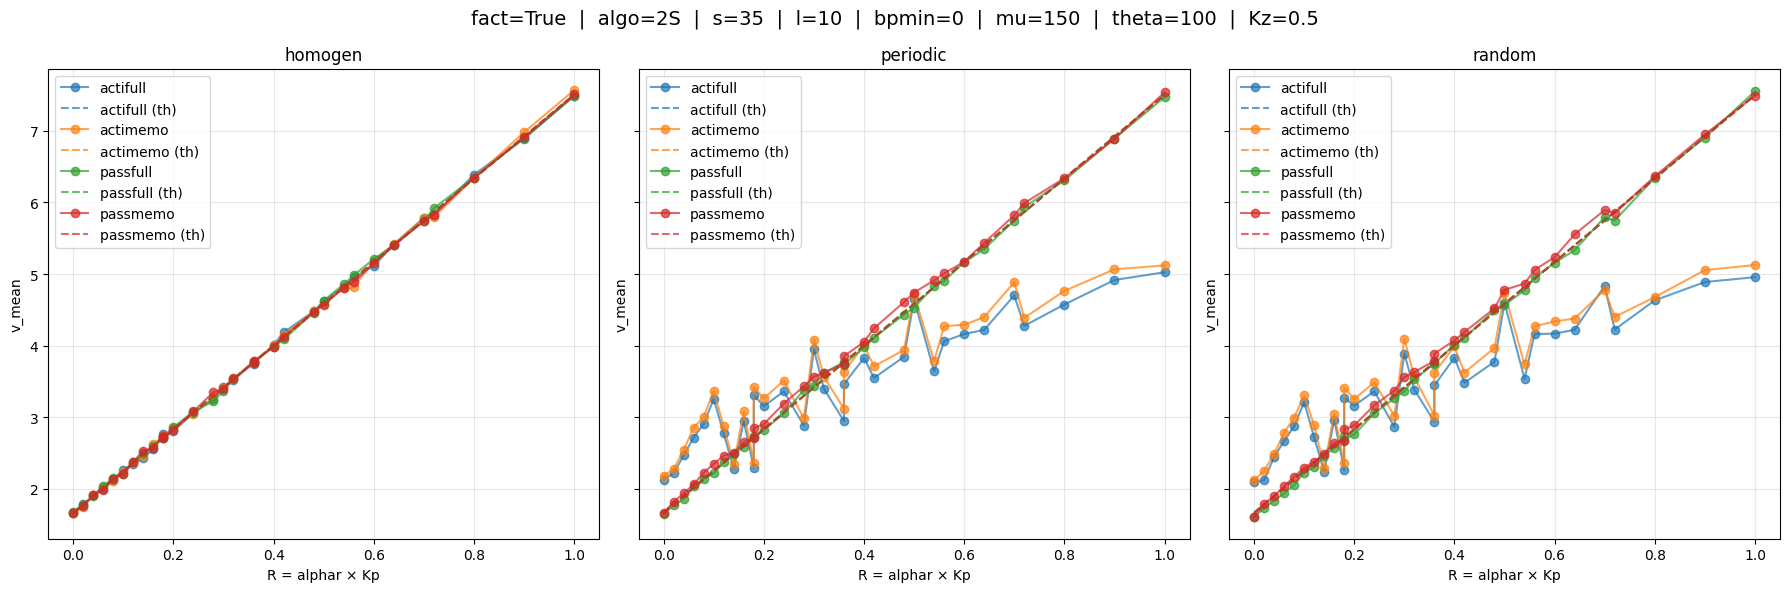

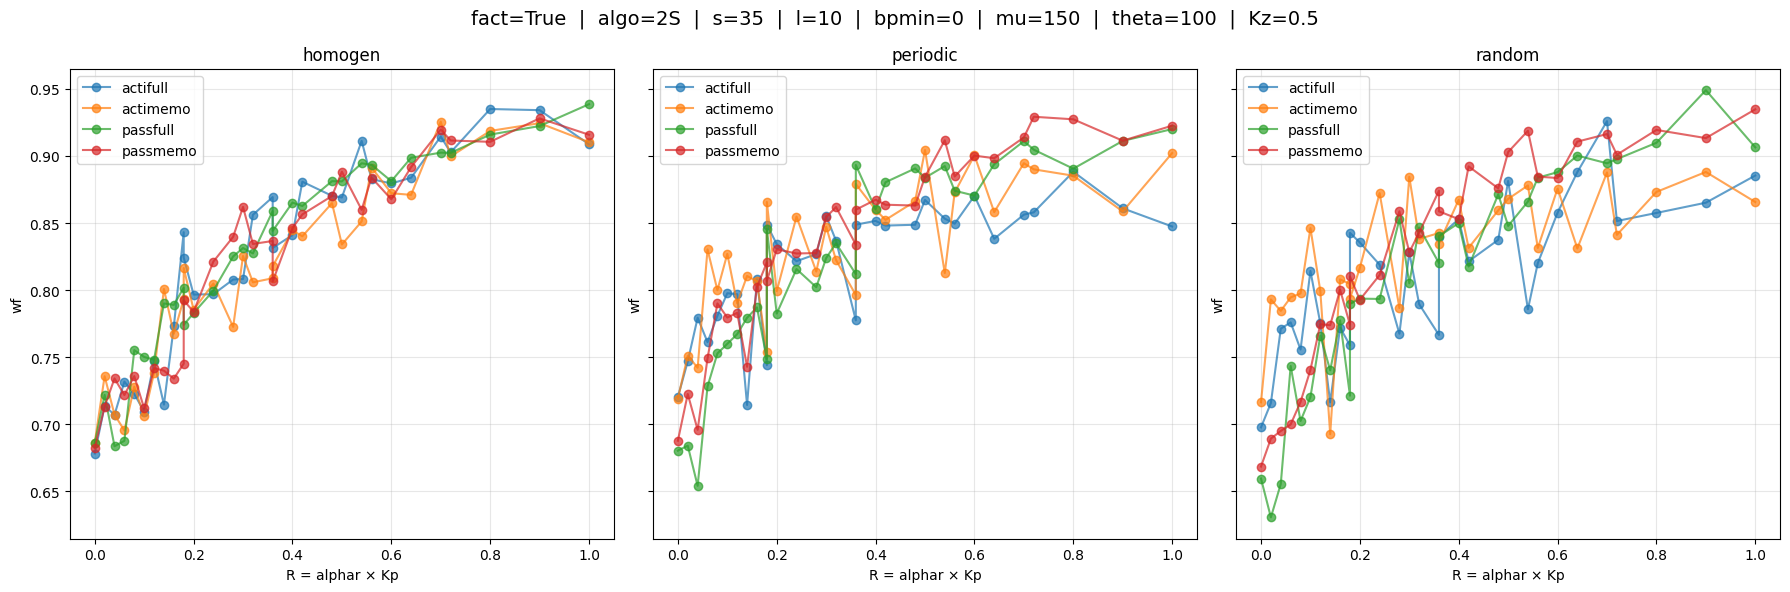

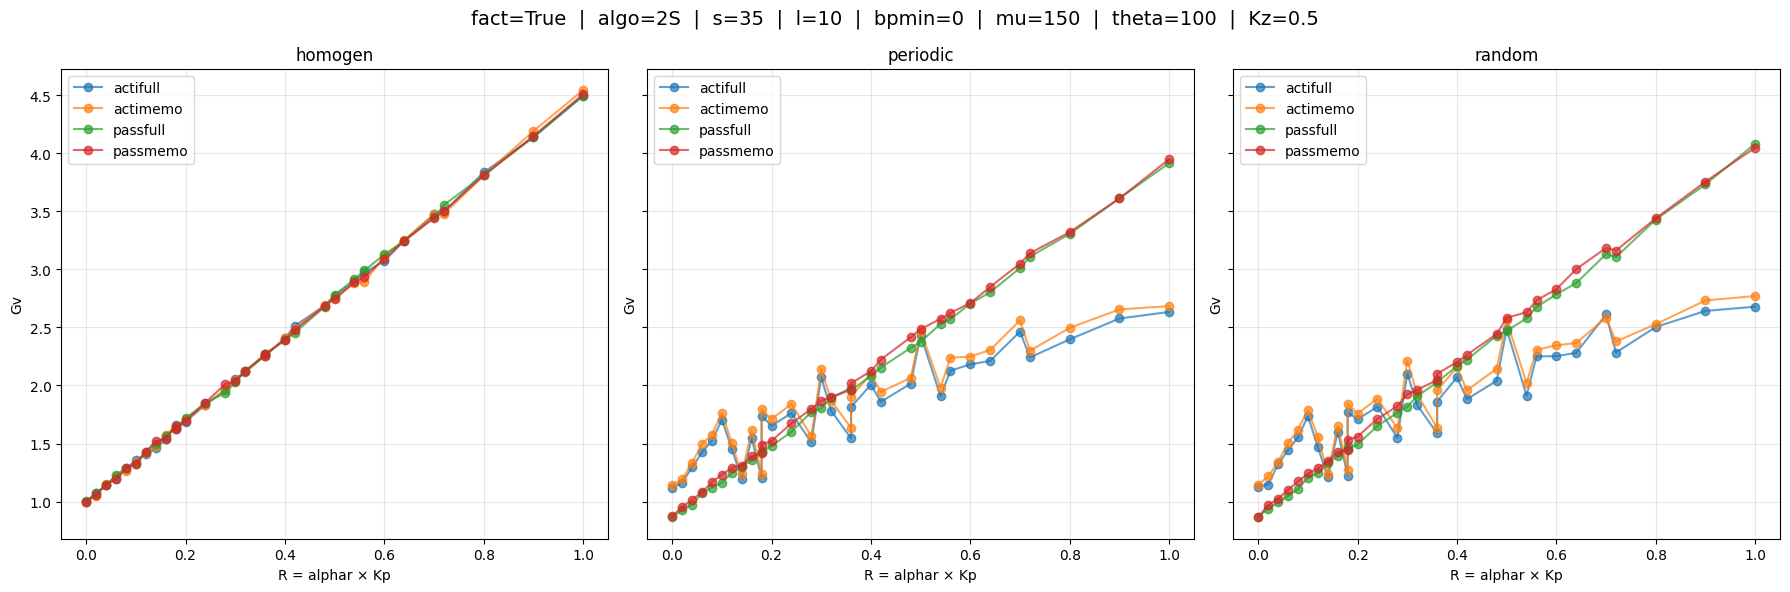

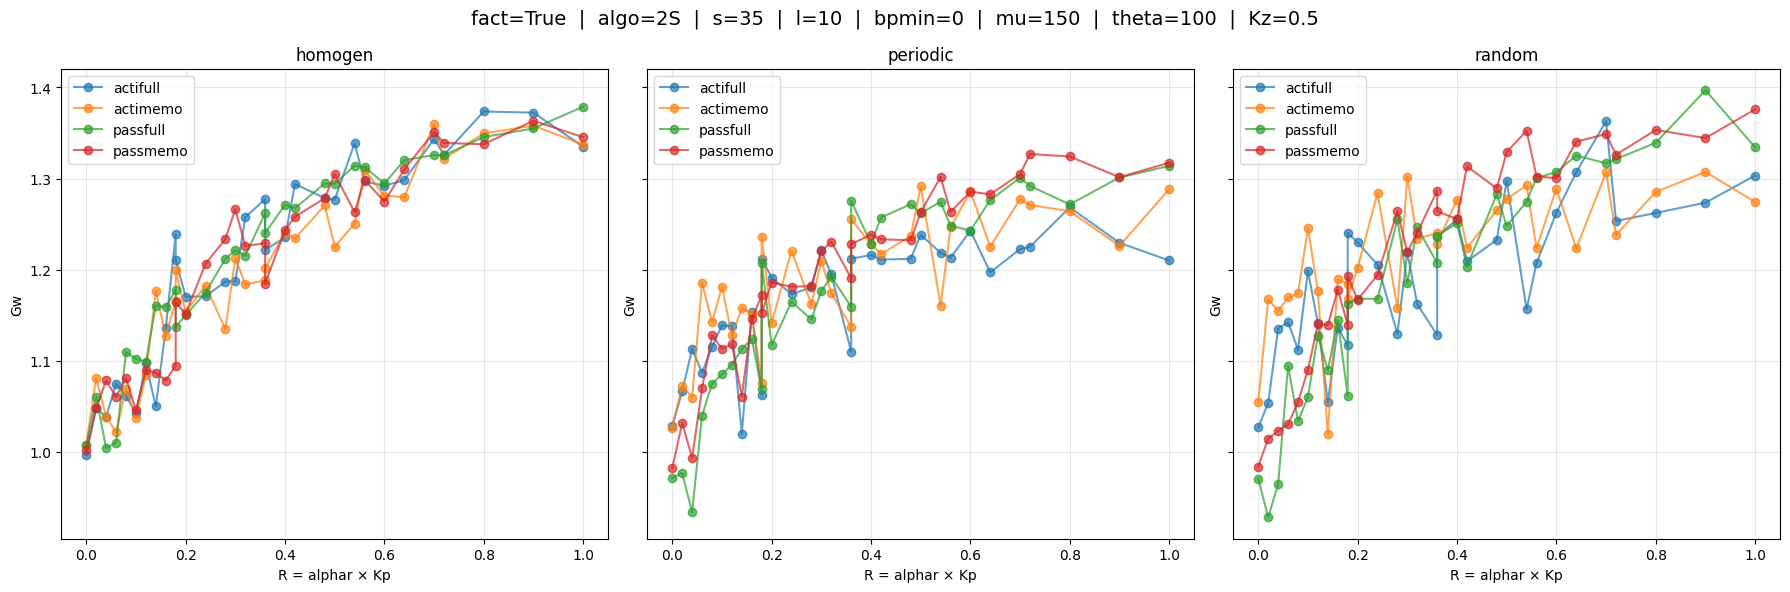

In [26]:
# ── Scenarios in function of K and modes ──────────────────────────────────────────────────────────────────────

def plot_by_landscape(
    df_work,
    lands,
    modes,
    params_fixed,
    y_col="v_mean",
    y_th_col=None,        # None par défaut = pas de courbe théorique
):
    n_lands = len(lands)
    fig, axes = plt.subplots(
        ncols=n_lands, nrows=1,
        figsize=(6 * n_lands, 6),
        sharey=True
    )
    if n_lands == 1:
        axes = [axes]

    title = "  |  ".join(f"{k}={v}" for k, v in params_fixed.items())
    plt.suptitle(title, fontsize=14)

    for ax, land in zip(axes, lands):
        df_land = df_work.filter(pl.col("land") == land)
        ax.set_title(land)

        for mode in modes:
            agg_cols = [pl.col(y_col).mean()]
            if y_th_col is not None:
                agg_cols.append(pl.col(y_th_col).mean())

            df_solo = (
                df_land
                .filter(pl.col("mode") == mode)
                .group_by("R")
                .agg(agg_cols)
                .sort("R")
            )

            R    = df_solo["R"].to_numpy()
            y    = df_solo[y_col].to_numpy()

            line, = ax.plot(R, y, label=mode, marker="o", alpha=0.70)

            if y_th_col is not None:
                y_th = df_solo[y_th_col].to_numpy()
                ax.plot(R, y_th, label=f"{mode} (th)",
                        linestyle="--", color=line.get_color(),
                        marker="", alpha=0.70)

        ax.set_xlabel("R = alphar × Kp")
        ax.set_ylabel(y_col)
        ax.grid(True, which="both", alpha=0.30)
        ax.legend()

    plt.tight_layout()
    plt.show()


# v_mean
plot_by_landscape(df_work, lands, modes, params_fixed,
                  y_col="v_mean", y_th_col="v_mean_th")

# wf
plot_by_landscape(df_work, lands, modes, params_fixed,
                  y_col="wf", y_th_col=None)

# Gv
plot_by_landscape(df_work, lands, modes, params_fixed,
                  y_col="Gv", y_th_col=None)

# Gw
plot_by_landscape(df_work, lands, modes, params_fixed,
                  y_col="Gw", y_th_col=None)


# Need to compare Kz = Kp because Kz = 0 means FACT is almost like closing even more or repulsing loop extrusion

# II.3 : STUDYING - 

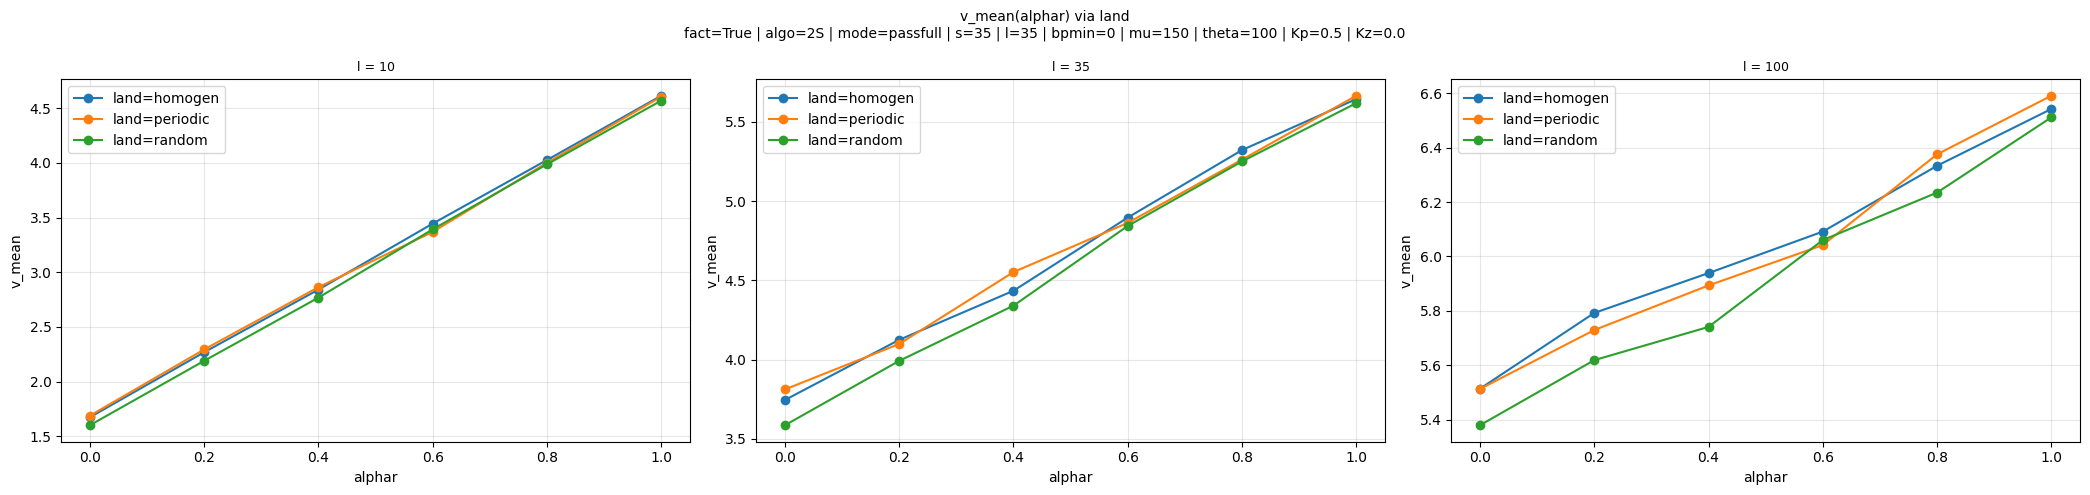

In [27]:
def plot_fact_data(
    df        : pl.DataFrame,
    x         : str,
    y         : str,
    param     : str,
    fixed     : dict = {},
    ax        : plt.Axes = None,
    title     : str = None,
    marker    : str = "o",
) -> plt.Axes:
    """
    Trace y(x) pour chaque valeur de `param`, les autres paramètres étant fixés.

    Args:
        df     : DataFrame source (df_all)
        x      : colonne pour l'axe X
        y      : colonne pour l'axe Y
        param  : colonne dont on fait varier les valeurs (une courbe par valeur)
        fixed  : dict {colonne: valeur} des paramètres à fixer via filtre
        ax     : axes matplotlib existant (sinon en crée un nouveau)
        title  : titre du graphique (auto-généré si None)
        marker : marqueur matplotlib
    """
    # Filtrage
    filters = [pl.col(k) == v for k, v in fixed.items() if v is not None]
    df_filtered = df.filter(pl.all_horizontal(filters)) if filters else df

    # Axe
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    # Une courbe par valeur de param
    for val in sorted(df_filtered[param].unique().to_list()):
        df_solo = df_filtered.filter(pl.col(param) == val).sort(x)
        ax.plot(df_solo[x].to_numpy(), df_solo[y].to_numpy(), label=f"{param}={val}", marker=marker)

    # Titre auto si non fourni
    if title is None:
        fixed_str = " | ".join(f"{k}={v}" for k, v in fixed.items() if v is not None)
        title = f"{y}({x})  —  par {param}" + (f"\n{fixed_str}" if fixed_str else "")

    ax.set_title(title, fontsize=9)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

    return ax


# Multi
x     = "alphar"
y     = "v_mean"
param = "land"
vary  = "l"

ls = sorted(df_all[vary].unique().to_list())
fig, axes = plt.subplots(ncols=len(ls), nrows=1, figsize=(7*len(ls), 5))

fixed_base = {
    "fact"      : True,
    "algo"      : "2S",
    "mode"      : "passfull",
    "s"         : 35,
    "l"         : 35,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 100,
    "Kp"        : 0.50,
    "Kz"        : 0.00      # Meaning no contribution from the fact to beeing dynamic
}

for ax, l_val in zip(axes, ls):
    plot_fact_data(
        df    = df_all,
        x     = x,
        y     = y,
        param = param,
        fixed = {**fixed_base, "l": l_val},
        ax    = ax,
        title = f"l = {l_val}",
    )

suptitle_str = " | ".join(f"{k}={v}" for k, v in fixed_base.items())
plt.suptitle(f"{y}({x}) via {param}\n{suptitle_str}", fontsize=10)
plt.tight_layout()
plt.show()

# II.4 : STUDYING - 

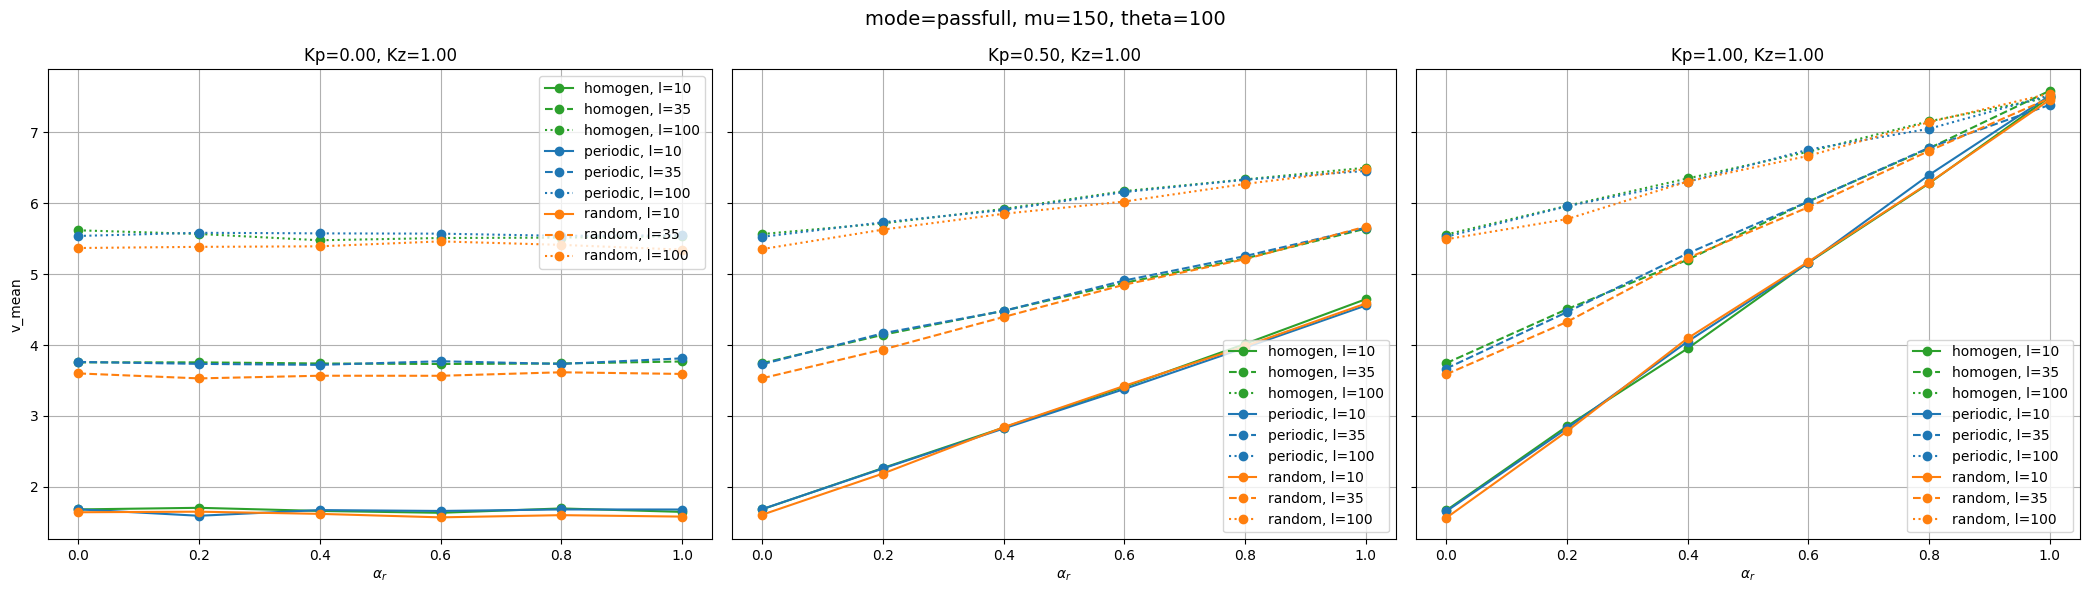

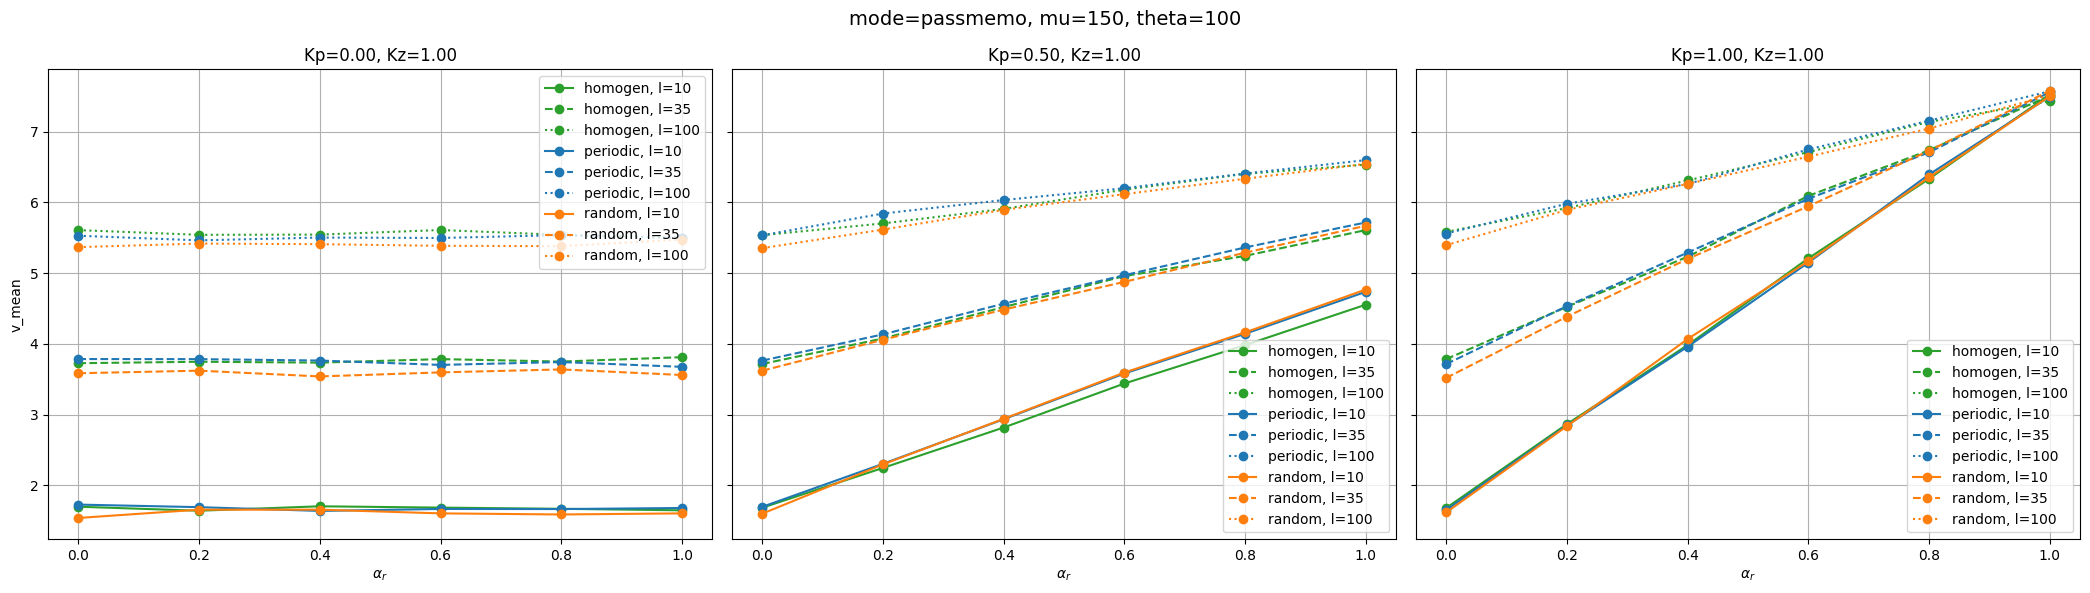

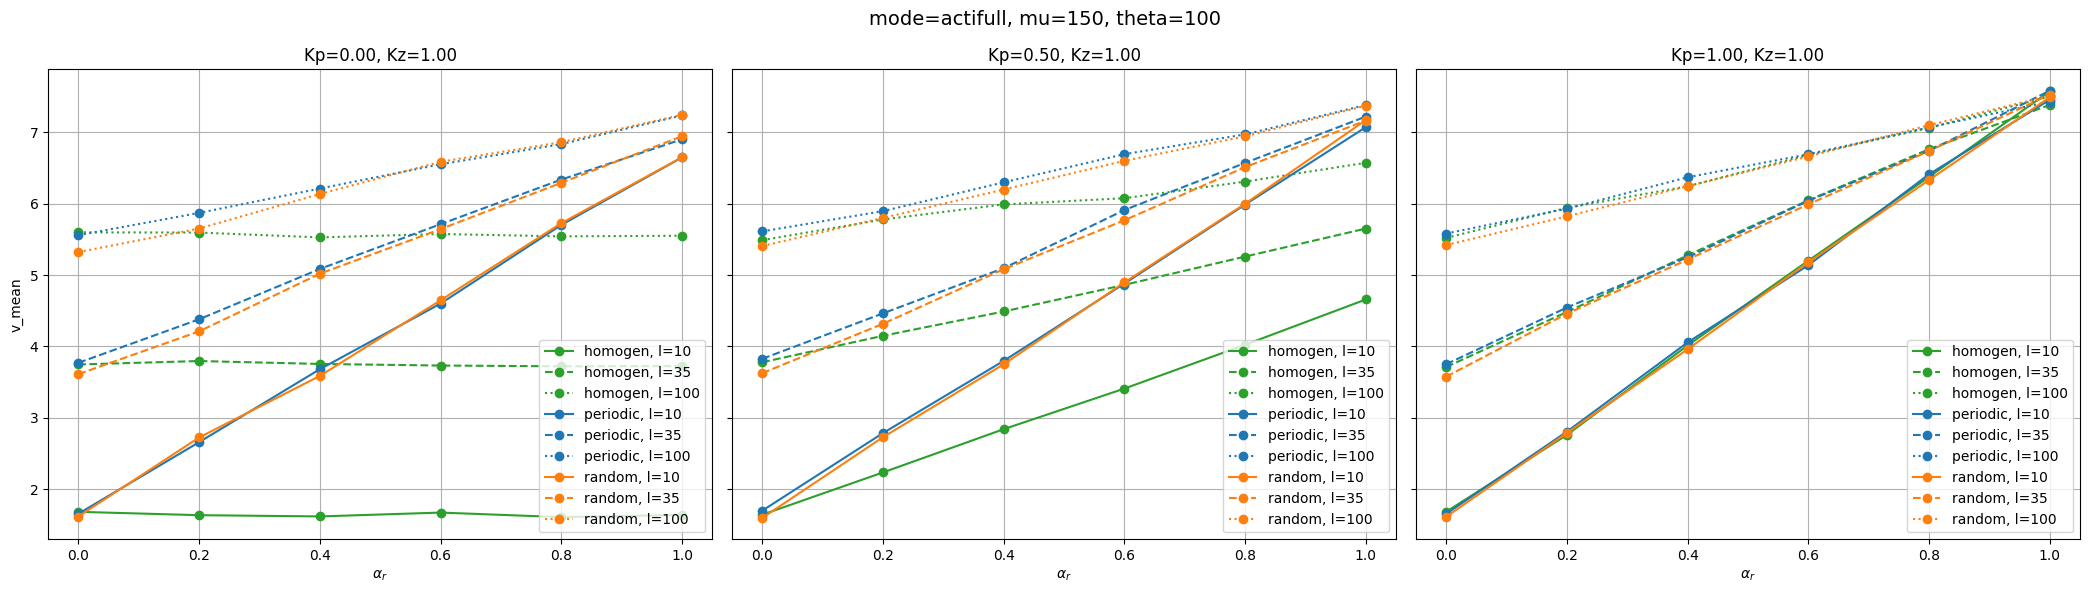

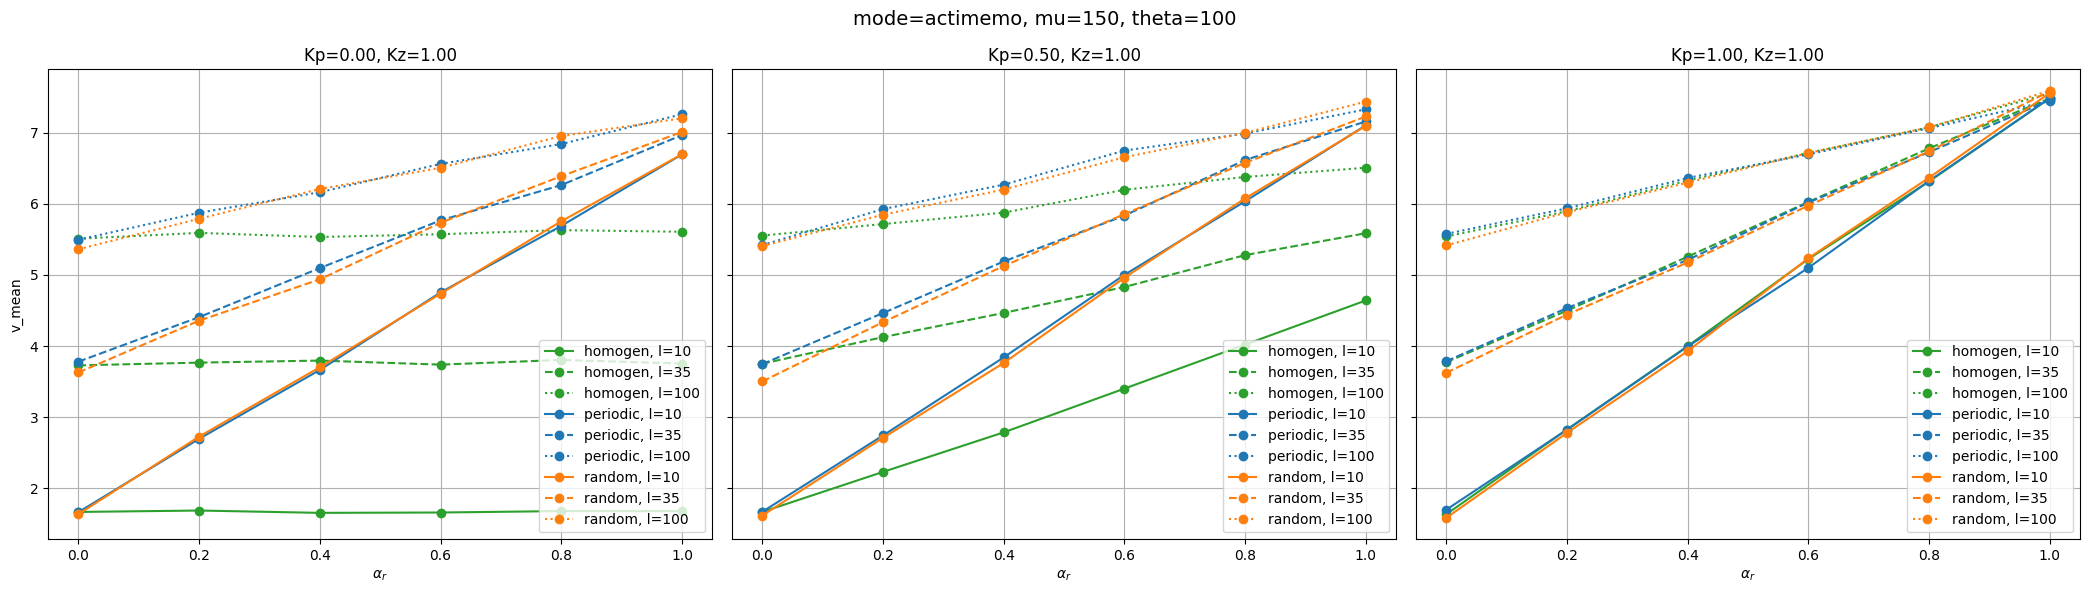

In [11]:
from itertools import product

# Couleurs par land
lands_colors = {
    "periodic"    : "tab:blue",
    "random"      : "tab:orange",
    "homogen"     : "tab:green",
}

# Styles par l (ordonnés)
ls_sorted  = np.sort(ls)
linestyles = {
    ls_sorted[0]: "-",
    ls_sorted[1]: "--",
    ls_sorted[2]: ":",
}

def plot_vmean_vs_alphar_subplots(df_all, value, mode, Kp_list, Kz=0.00):
    n = len(Kp_list)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), sharey=True)
    if n == 1:
        axes = [axes]

    fig.suptitle(f"mode={mode}, mu={mu}, theta={theta}", fontsize=14)
    lands = np.unique(df_all["land"].to_numpy())

    for ax, Kp in zip(axes, Kp_list):
        for land, l in product(lands, ls):
            df_data = df_all.filter(
                (pl.col("mode")      == mode)      &
                (pl.col("land") == land) &
                (pl.col("l")         == l)         &
                (pl.col("mu")        == mu)        &
                (pl.col("theta")     == theta)     &
                (pl.col("Kp").is_close(Kp))        &
                (pl.col("Kz").is_close(Kz))
            )
            if df_data.height == 0:
                continue

            alphar  = df_data["alphar"].to_numpy()
            to_plot = df_data[value].to_numpy()

            ax.plot(
                alphar, to_plot,
                color     = lands_colors[land],
                linestyle = linestyles[l],
                marker    = "o",
                label     = f"{land}, l={l}",
            )

        ax.set_title(f"Kp={Kp:.2f}, Kz={Kz:.2f}")
        ax.set_xlabel(r"$\alpha_r$")
        ax.grid(True)
        ax.legend(frameon=True)

    axes[0].set_ylabel(value)
    plt.tight_layout()
    plt.show()

# Values
Kps = [0.00, 0.50, 1.00]
Kz  = 1.00

# Calls
plot_vmean_vs_alphar_subplots(
    df_all,
    value   = "v_mean",
    mode    = "passfull",
    Kp_list = Kps,
    Kz      = Kz,
)
plot_vmean_vs_alphar_subplots(
    df_all,
    value   = "v_mean",
    mode    = "passmemo",
    Kp_list = Kps,
    Kz      = Kz,
)
plot_vmean_vs_alphar_subplots(
    df_all,
    value   = "v_mean",
    mode    = "actifull",
    Kp_list = Kps,
    Kz      = Kz,
)
plot_vmean_vs_alphar_subplots(
    df_all,
    value   = "v_mean",
    mode    = "actimemo",
    Kp_list = Kps,
    Kz      = Kz,
)

# III.0 : HEATMAPS - FUNCTION

In [ ]:
def plot_single_heatmap(
    df: pl.DataFrame,
    land: str,
    l: int,
    value: str,
    ax,
    log_plot: bool = False,
    cmap: str = "plasma",
):
    """
    Plot a heatmap of `value` as a function of alphar (x) and K (y)
    for a given land and l.
    """
    # 1) Filtrage (alphar = 0 exclu)
    df_heat = (
        df.filter(
            (pl.col("land") == land) &
            (pl.col("l") == l) &
            (pl.col("alphar") > 0)
        )
        .select(["alphar", "Kp", value])
        .sort(["Kp", "alphar"])
    )

    if df_heat.height == 0:
        ax.set_title(f"{land} -- l={l}\n(no data)")
        return None

    # 2) Pivot 100% Polars → pas besoin de pandas
    pivot_pl = (
        df_heat
        .group_by(["Kp", "alphar"])
        .agg(pl.col(value).mean())
        .sort(["Kp", "alphar"])
        .pivot(on="alphar", index="Kp", values=value)
        .sort("Kp")
    )

    # Extraction des axes et de la grille
    Y = pivot_pl["Kp"].to_numpy()                          # lignes  (K)
    X = np.array(                                          # colonnes (alphar)
        sorted(float(c) for c in pivot_pl.columns if c != "Kp")
    )
    col_order = [str(x) for x in X]                       # ordre cohérent
    Z2D = pivot_pl.select(col_order).to_numpy().astype(float)

    X_grid, Y_grid = np.meshgrid(X, Y)

    # 3) Scale (lin / log)
    if log_plot:
        Z2D = np.log2(Z2D)
        vmin, vmax = -2, 2
    else:
        if value == "v_mean":
            vmin, vmax = 0, 7
        elif value == "vc_mean":
            vmin, vmax = 0, 50
        elif value == "vc_med":
            vmin, vmax = 0, 1
        elif value =="wf":
            vmin, vmax = 0, 1
        else:
            vmin, vmax = None, None

    # 4) Plot
    c = ax.pcolormesh(
        X_grid, Y_grid, Z2D,
        cmap=cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"{land} -- l={l}")
    ax.set_xlabel(r"$\alpha_r$")
    ax.set_ylabel(r"$K_{p} = \frac{k_B}{k_B + k_U}$")

    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    return c


def plot_heatmaps(df_all: pl.DataFrame, value: str, cmap: str = "plasma"):
    """Trace les heatmaps pour toutes les combinaisons (land, l)."""
    lands = sorted(df_all["land"].unique().to_list())
    ls = sorted(df_all["l"].unique().to_list())

    n_rows = len(lands)
    n_cols = len(ls)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        constrained_layout=True,
    )
    axes_2d = np.array(axes).reshape(n_rows, n_cols)
    fig.suptitle(value)

    last_c = None
    for i, land in enumerate(lands):
        for j, l in enumerate(ls):
            c = plot_single_heatmap(df_all, land, l, value, axes_2d[i, j], cmap=cmap)
            if c is not None:
                last_c = c

    if last_c is not None:
        fig.colorbar(last_c, ax=axes_2d.ravel().tolist(), orientation='vertical', label=value)

    plt.show()

# III.1 : HEATMAPS - v_mean

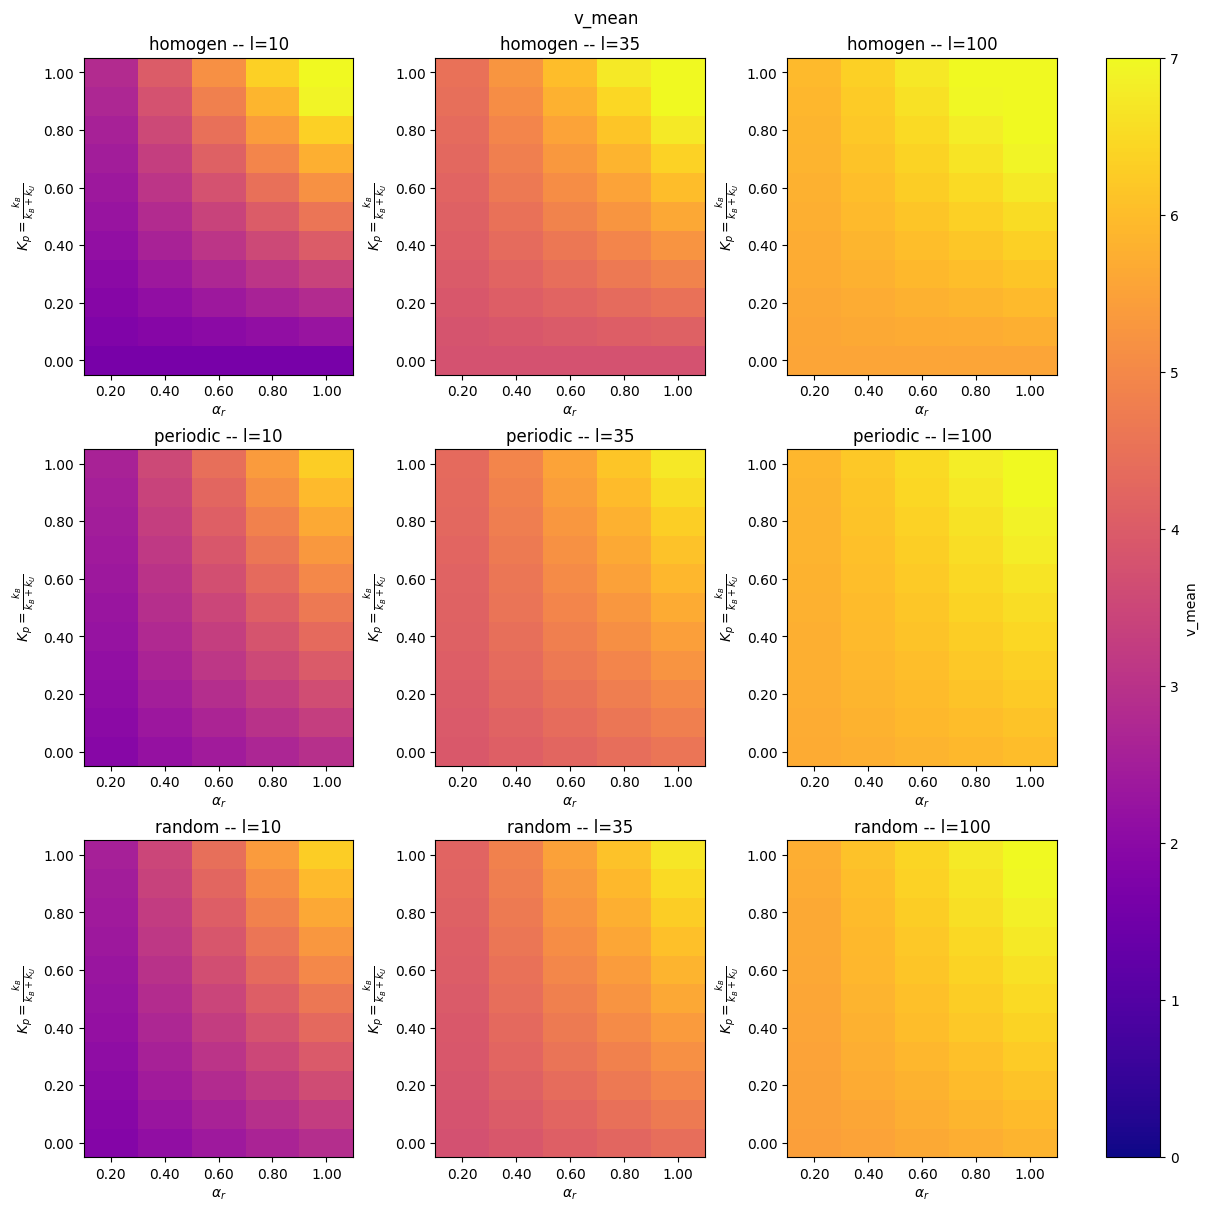

In [16]:
# ── Visualisation ───────────────────────────────────────────────────────────
plot_heatmaps(df_all, "v_mean")

# III.2 : HEATMAPS - wf

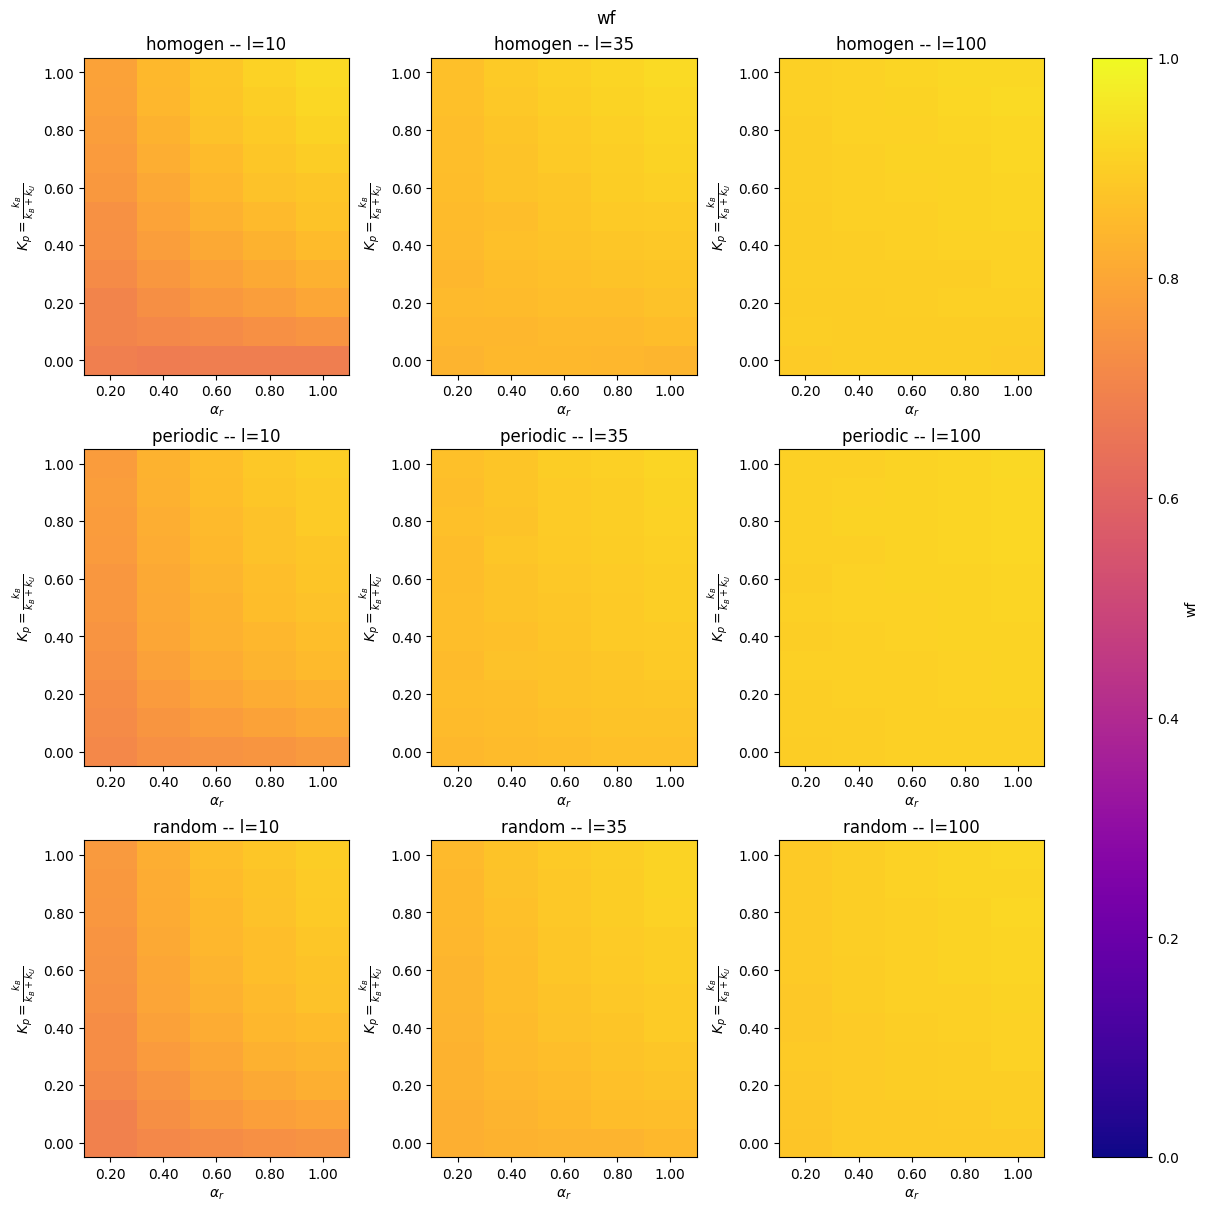

In [17]:
# ── Visualisation ───────────────────────────────────────────────────────────
plot_heatmaps(df_all, "wf")

# III.3 : HEATMAPS - Gv

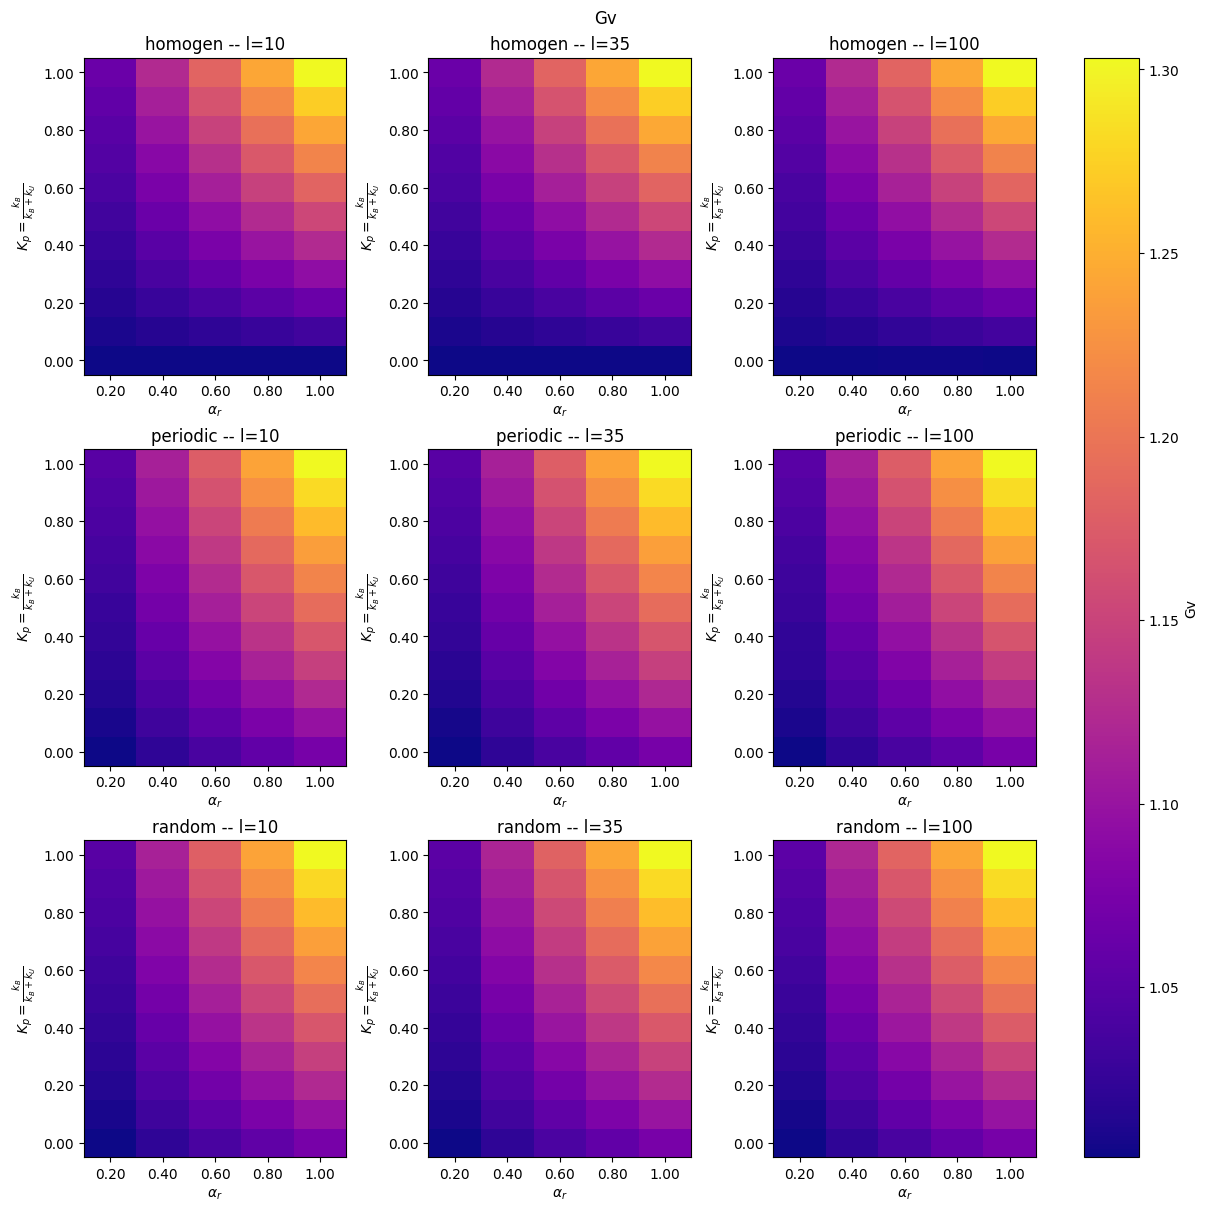

In [18]:
# ── Visualisation ───────────────────────────────────────────────────────────
plot_heatmaps(df_all, "Gv")

# III.4 : HEATMAPS - Gw

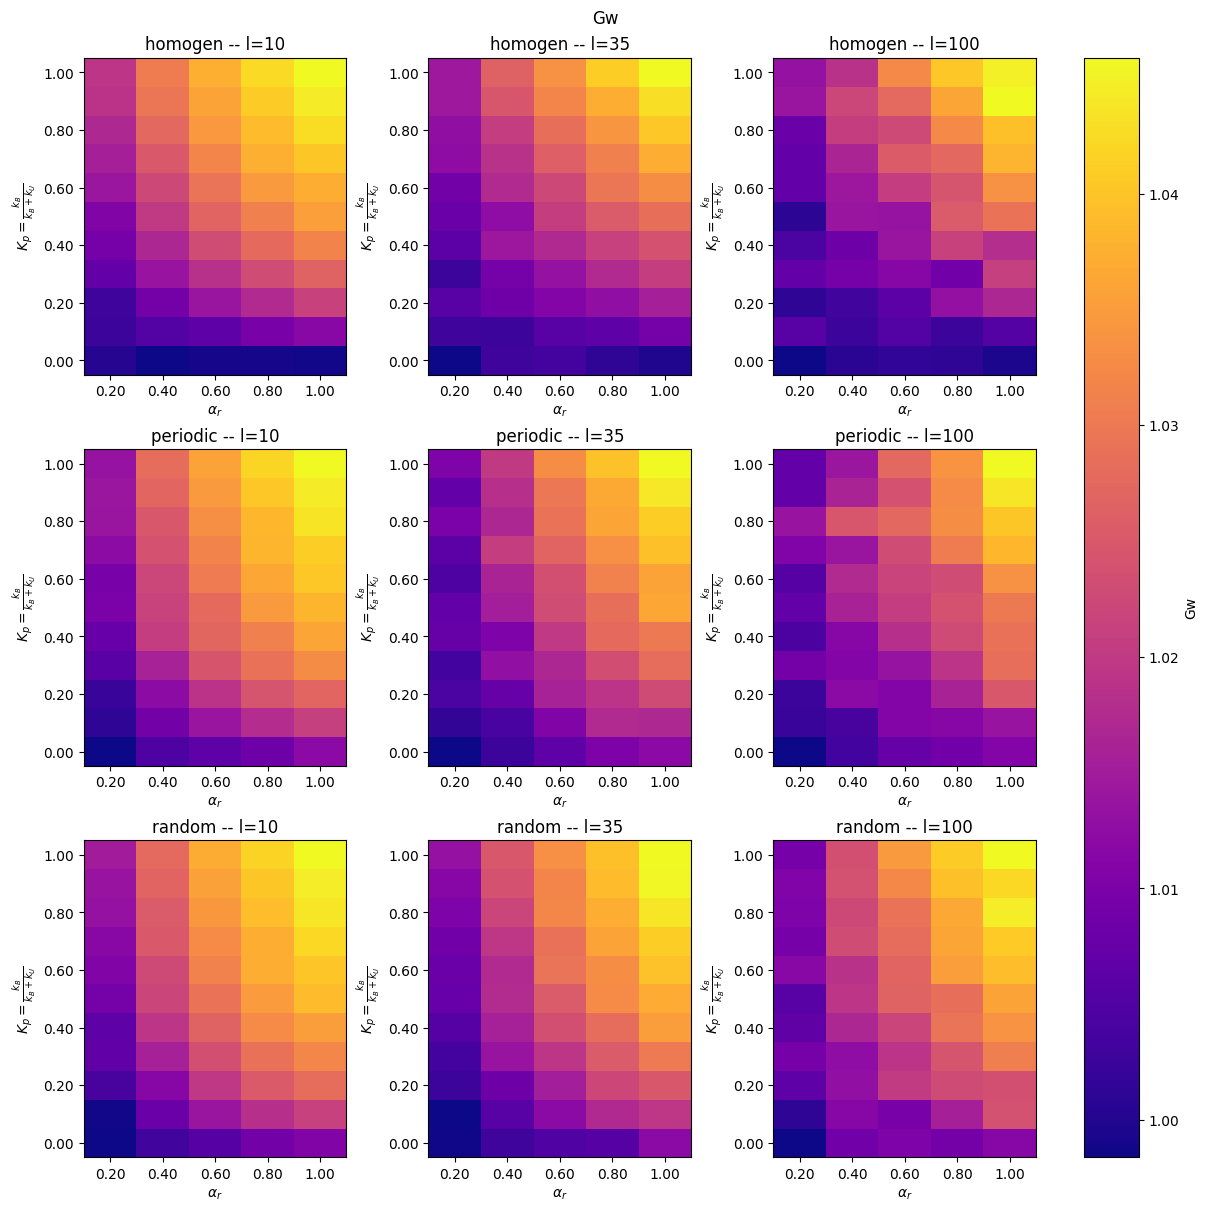

In [19]:
# ── Visualisation ───────────────────────────────────────────────────────────
plot_heatmaps(df_all, "Gw")

# IV.1 : MODES - 

# IV.2 : MODES - 

# IV.3 : MODES - 

/tmp/ipykernel_218477/1977950660.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


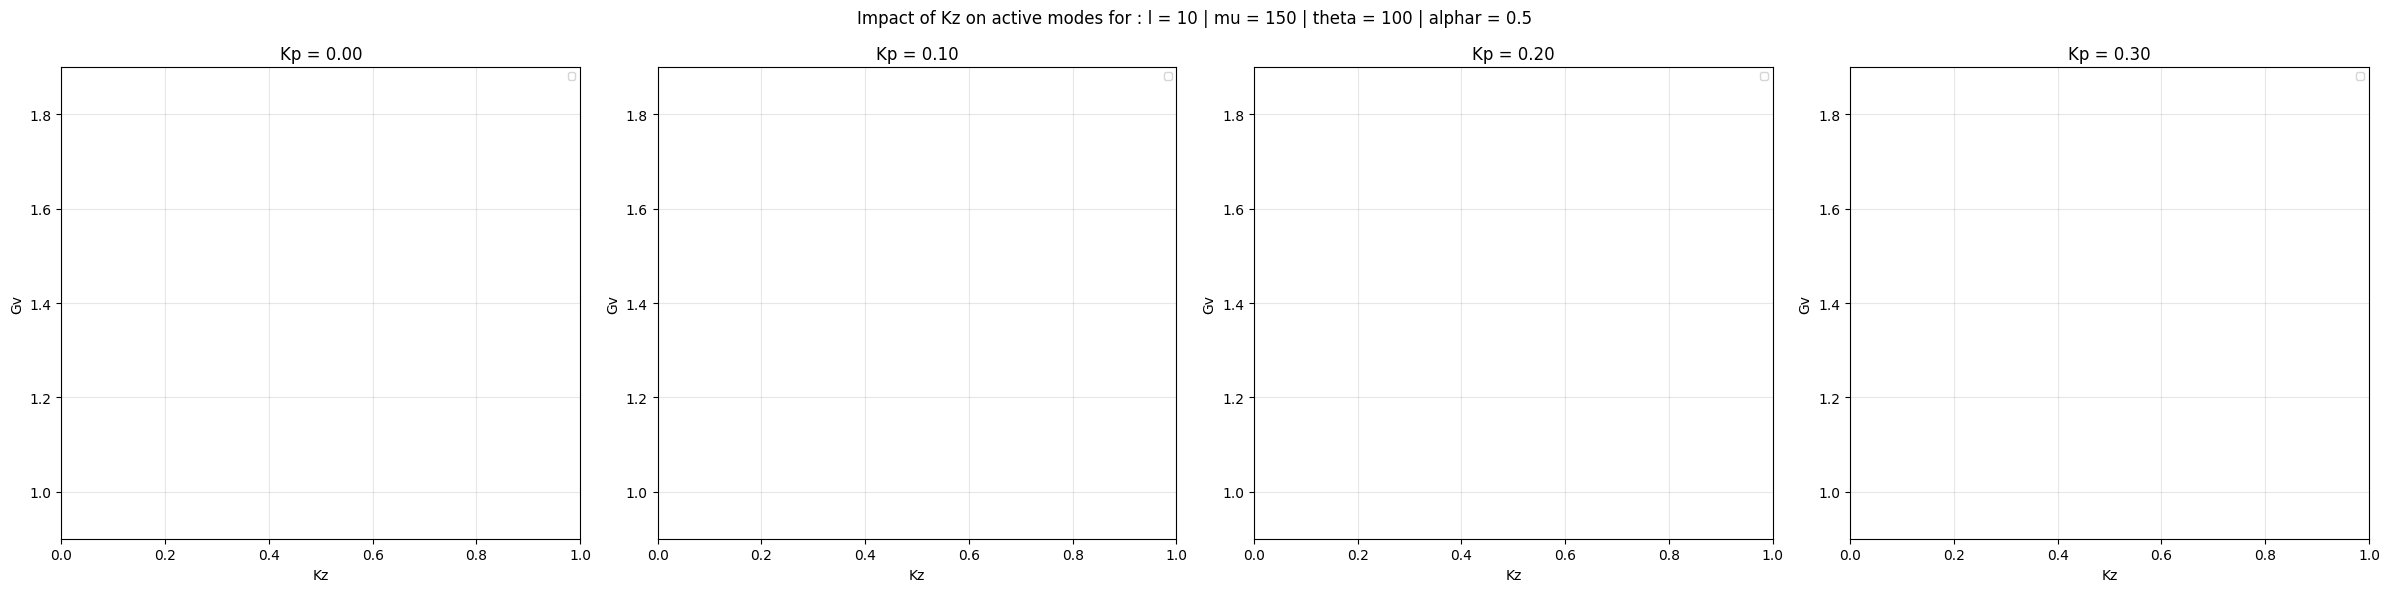

In [13]:
# ── DataFrame ───────────────────────────────────────────────────────────

# Fixed Values
acti_modes = ["actifull", "actimemo"]
Kps        = [0.00, 0.10, 0.20, 0.30]
l          = 10
mu         = 150
theta      = 100
alphar     = 0.50

df_acti = df_all.clone().filter(
    (pl.col("l") == l) &
    (pl.col("mu") == mu) &
    (pl.col("theta") == theta) &
    (pl.col("alphar") == alphar) &
    (pl.col("mode").is_in(acti_modes))
)

# Value
value = "Gv"

# ── Style maps ───────────────────────────────────────────────────────────
lands   = sorted(df_acti["land"].unique().to_list())
land_colors  = {land: color for land, color in zip(lands, ["steelblue", "tomato", "seagreen"])}
mode_styles  = {"actifull": ("o", "-"), "actimemo": ("s", "--")}

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=1, ncols=len(Kps), figsize=(24, 6))
fig.suptitle(
    "Impact of Kz on active modes for : "
    f"l = {l} | mu = {mu} | theta = {theta} | alphar = {alphar}"
)

for ax, Kp in zip(axes, Kps):
    ax.set_title(f"Kp = {Kp:.2f}")
    for land in lands:
        for mode in acti_modes:
            marker, linestyle = mode_styles[mode]
            df_plot = (
                df_acti
                .filter(
                    (pl.col("Kp").is_close(Kp)) &
                    (pl.col("land") == land) &
                    (pl.col("mode") == mode)
                )
                .sort("Kz")
            )
            if df_plot.is_empty():
                print(f"[WARN] No data for Kp={Kp}, land={land}, mode={mode}")
                continue
            x = df_plot["Kz"].to_numpy()
            y = df_plot[value].to_numpy()
            ax.plot(x, y,
                    color=land_colors[land],
                    marker=marker,
                    linestyle=linestyle,
                    label=f"{mode} | {land}")
    ax.set_xlabel("Kz")
    ax.set_ylabel(value)
    ax.set_ylim([0.90, 1.90])
    ax.grid(True, alpha=0.30)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

[WARN] No data for alphar=0.5, l=10, land=homogen, mode=actifull
[WARN] No data for alphar=0.5, l=10, land=homogen, mode=actimemo
[WARN] No data for alphar=0.5, l=10, land=periodic, mode=actifull
[WARN] No data for alphar=0.5, l=10, land=periodic, mode=actimemo
[WARN] No data for alphar=0.5, l=10, land=random, mode=actifull
[WARN] No data for alphar=0.5, l=10, land=random, mode=actimemo
[WARN] No data for alphar=0.5, l=35, land=homogen, mode=actifull
[WARN] No data for alphar=0.5, l=35, land=homogen, mode=actimemo
[WARN] No data for alphar=0.5, l=35, land=periodic, mode=actifull
[WARN] No data for alphar=0.5, l=35, land=periodic, mode=actimemo
[WARN] No data for alphar=0.5, l=35, land=random, mode=actifull
[WARN] No data for alphar=0.5, l=35, land=random, mode=actimemo
[WARN] No data for alphar=0.5, l=100, land=homogen, mode=actifull
[WARN] No data for alphar=0.5, l=100, land=homogen, mode=actimemo
[WARN] No data for alphar=0.5, l=100, land=periodic, mode=actifull
[WARN] No data for al

/tmp/ipykernel_218477/4083891711.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


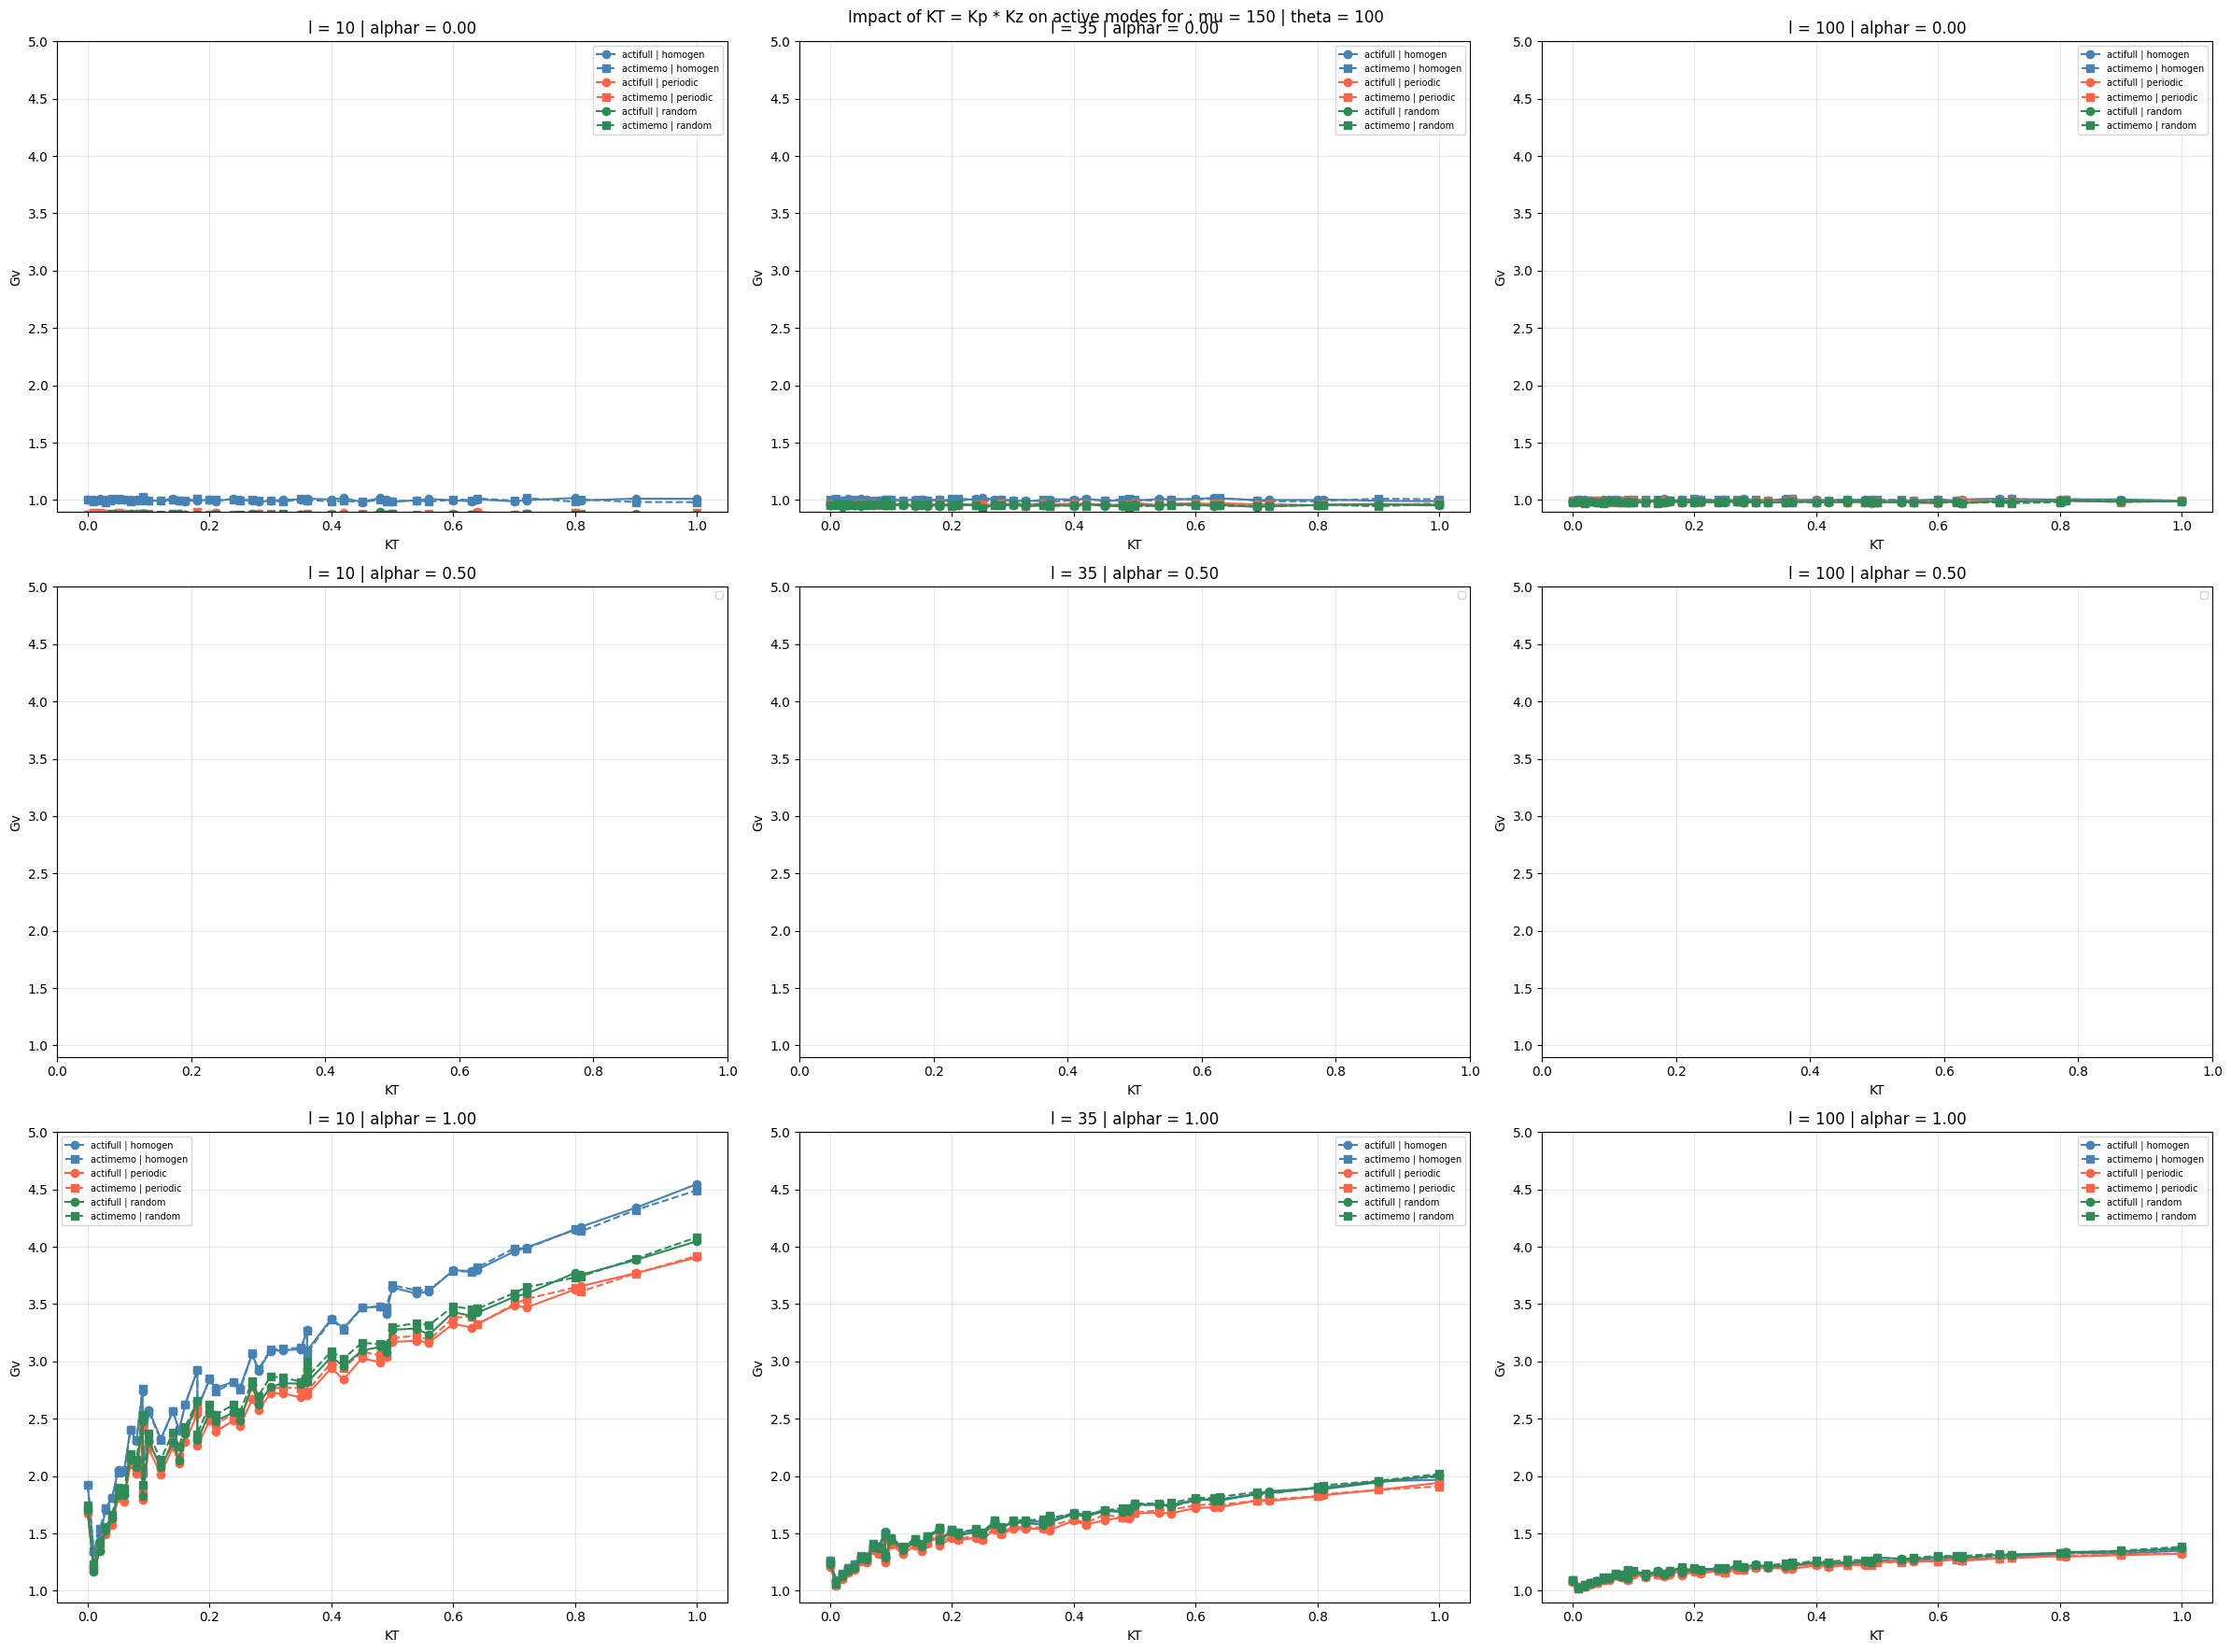

In [14]:
# ── DataFrame ───────────────────────────────────────────────────────────
# Fixed Values
acti_modes = ["actifull", "actimemo"]
ls         = np.unique(df_all["l"].to_numpy())
alphars    = [0.00, 0.50, 1.00]
mu         = 150
theta      = 100

df_acti = (
    df_all.clone()
    .with_columns(
        (pl.col("Kp") * pl.col("Kz")).alias("KT")
    )
    .filter(
        (pl.col("mu") == mu) &
        (pl.col("theta") == theta) &
        (pl.col("mode").is_in(acti_modes))
    )
)

# Value
value = "Gv"

# ── Style maps ───────────────────────────────────────────────────────────
lands  = sorted(df_acti["land"].unique().to_list())
land_colors = {land: color for land, color in zip(lands, ["steelblue", "tomato", "seagreen"])}
mode_styles = {"actifull": ("o", "-"), "actimemo": ("s", "--")}

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=len(alphars), ncols=len(ls), figsize=(24, 6 * len(alphars)))
fig.suptitle(
    "Impact of KT = Kp * Kz on active modes for : "
    f"mu = {mu} | theta = {theta}"
)

for row, alphar in enumerate(alphars):
    for col, l in enumerate(ls):
        ax = axes[row, col]
        ax.set_title(f"l = {l} | alphar = {alphar:.2f}")
        for land in lands:
            for mode in acti_modes:
                marker, linestyle = mode_styles[mode]
                df_plot = (
                    df_acti
                    .filter(
                        (pl.col("alphar").is_close(alphar)) &
                        (pl.col("l") == l) &
                        (pl.col("land") == land) &
                        (pl.col("mode") == mode)
                    )
                    .group_by("KT")
                    .agg(pl.col(value).mean())
                    .sort("KT")
                )
                if df_plot.is_empty():
                    print(f"[WARN] No data for alphar={alphar}, l={l}, land={land}, mode={mode}")
                    continue
                x = df_plot["KT"].to_numpy()
                y = df_plot[value].to_numpy()
                ax.plot(x, y,
                        color=land_colors[land],
                        marker=marker,
                        linestyle=linestyle,
                        label=f"{mode} | {land}")
        ax.set_xlabel("KT")
        ax.set_ylabel(value)
        ax.set_ylim([0.90, 5.00])
        ax.grid(True, alpha=0.30)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# V : OBSERVATIONS

Plus le linker est petit plus la différence est importante : des facteurs de transcription efficaces en fréquences permettent à des chromatines denses d'être extrudées vite

Le remodellage aide plus dans les cas aléatoires que dans les cas périodiques

# .